# 01211373 : Machine Learning and Programming for Industry

## Lecture 4 Supplement 1 : Ensemble learning, and random forests

In lecture 2 we introduced decison tree. Now we discuss ensemble methods to combine different classifiers into a meta-classfier that has better generalization performance than each individual classifier alone. random forest can be considered as an ensemble of decision trees.



### 4.1 Ensemble learning 

From wikipedia https://en.wikipedia.org/wiki/Ensemble_learning 

"In statistics and machine learning, ensemble methods use multiple learning algorithms to obtain better predictive performance than could be obtained from any of the constituent learning algorithms alone. Unlike a statistical ensemble in statistical mechanics, which is usually infinite, a machine learning ensemble consists of only a concrete finite set of alternative models, but typically allows for much more flexible structure to exist among those alternatives."

**Note :** Our ensemble discussion here follows [1]. We focus on experimenting with the provided code. Advanced details may be omitted.

#### 4.1.1 Ensemble approach based on majority voting

**Note :** We have abused the term "majority vote" in place of "plurality vote." Read explanation in [1]

Figure 4.1 illustrates the concept of a general ensemble approach using majority voting. To predict a class label via simple majority or plurality voting, we can combine the predicted class labels of each individual classifier, $C_j$, and select the class label, $\hat{y}$ , that received the most votes.
$$
\hat{y} = mode(C_1(x), C_2(x),\ldots,C_m(x)) \tag{5.6}
$$
In statistics, the mode is the most frequent event or result in a set. For example $mode(3,2,3,5,4,3,4) = 3.$

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_02.png" width=800 />

Figure 4.1 A general ensemble approach (from Figure 7.2 of [1])

Read [1] for more details. Here we provide only the code. 

This cell below just verifies p. 207 of [1].


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import comb
import math


def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

In [3]:
ensemble_error(n_classifier=11, error=0.25)

np.float64(0.03432750701904297)

After we have implemented the ensemble_error function, we can compute the ensemble error rates 
for a range of different base errors from 0.0 to 1.0 to visualize the relationship between ensemble and 
base errors in a line graph:

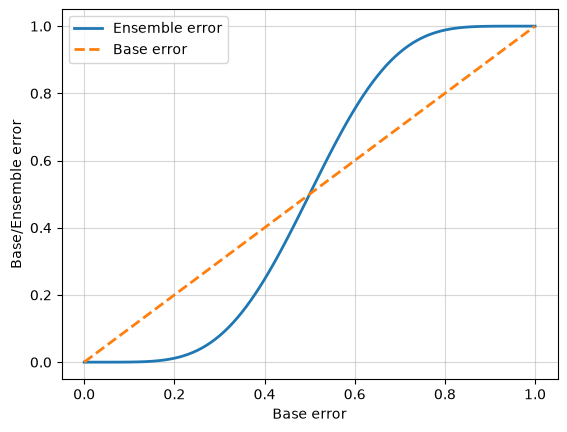

In [4]:
error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error)
              for error in error_range]
plt.plot(error_range, 
         ens_errors, 
         label='Ensemble error', 
         linewidth=2)

plt.plot(error_range, 
         error_range, 
         linestyle='--',
         label='Base error',
         linewidth=2)

plt.xlabel('Base error')
plt.ylabel('Base/Ensemble error')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

From the result, the error probability of an ensemble is always better than the error of an individual base classifier as long as $\epsilon \lt 0.5$. (A base classifier with $\epsilon \gt 0.5$ performs worse than random guessing so it's useless.)

#### 4.1.2 Implementing a simple majority vote classifier

In this scetion we build a stronger meta-classifier that balances out different classification algorithms associated with individual weights for confidence. Mathematically, the weighted majority vote is defined as
$$
\hat{y} = \underset{i}{arg \;max} \sum_{j=1}^m w_j\chi_A(C_j(x)= i) \tag{5.7}
$$
where $w_j$ is a weight associated with a base classifier $C_j$, $\hat{y}$ is the predicted class label of the ensemble, $A$ is the set of unique class labels, and $\chi_A$ is the characteristic funciton or indicator function, which returns 1 if the predicted class of the jth classifier matches $i$, $C_j(x) = i$. For equal weight, (5.7) is simplified to
$$
\hat{y} = mode(C_1(x),C_2(x),\ldots, C_m(x)) \tag{5.8}
$$
See example on page 210 of [1].

To translate the concept of the weighted majority vote into Python code, we can use NumPy’s convenient
argmax and bincount functions, where bincount counts the number of occurrences of each
class label. The argmax function then returns the index position of the highest count, corresponding
to the majority class label (this assumes that class labels start at 0):




In [5]:
np.argmax(np.bincount([0, 0, 1], weights=[0.2, 0.2, 0.6]))

np.int64(1)

In [6]:
np.argmax(np.bincount([0, 0, 0, 1, 1], weights=[0.2, 0.2,0.2,0.2,0.2 ]))

np.int64(0)

Certain certain classifiers in
scikit-learn can also return the probability of a predicted class label via the predict_proba method. Using the predicted class probabilities instead of the class labels for majority voting can be useful
if the classifiers in our ensemble are well calibrated. The modified version of the majority vote for
predicting class labels from probabilities can be written as follows
$$
\hat{y} = \underset{i}{arg \;max} \sum_{j=1}^m w_jp_{ij} \tag{5.9}
$$
where $p_{ij}$ is the predicted probability of the jth classifier for class label $j$.

To implement the weighted majority vote based on class probabilities, we can again make use of
NumPy, using np.average and np.argmax


In [7]:
ex = np.array([[0.9, 0.1],
               [0.8, 0.2],
               [0.4, 0.6]])

p = np.average(ex, 
               axis=0, 
               weights=[0.2, 0.2, 0.6])
p

array([0.58, 0.42])

In [8]:
np.argmax(p)

np.int64(0)

Let's now implement MajorityVoteClassifier in Python.

In [9]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import _name_estimators
import numpy as np
import operator



# Scikit-learn 0.16 and newer requires reversing the parent classes
# See https://github.com/rasbt/machine-learning-book/discussions/205 for more details
import sklearn
base_classes = (ClassifierMixin, BaseEstimator) if sklearn.__version__ >= "0.16" else (BaseEstimator, ClassifierMixin)

# class MajorityVoteClassifier(BaseEstimator, 
#                             ClassifierMixin):

class MajorityVoteClassifier(*base_classes):

    """ A majority vote ensemble classifier

    Parameters
    ----------
    classifiers : array-like, shape = [n_classifiers]
      Different classifiers for the ensemble

    vote : str, {'classlabel', 'probability'} (default='classlabel')
      If 'classlabel' the prediction is based on the argmax of
        class labels. Else if 'probability', the argmax of
        the sum of probabilities is used to predict the class label
        (recommended for calibrated classifiers).

    weights : array-like, shape = [n_classifiers], optional (default=None)
      If a list of `int` or `float` values are provided, the classifiers
      are weighted by importance; Uses uniform weights if `weights=None`.

    """
    def __init__(self, classifiers, vote='classlabel', weights=None):

        self.classifiers = classifiers
        self.named_classifiers = {key: value for key, value
                                  in _name_estimators(classifiers)}
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):
        """ Fit classifiers.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Matrix of training examples.

        y : array-like, shape = [n_examples]
            Vector of target class labels.

        Returns
        -------
        self : object

        """
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"vote must be 'probability' or 'classlabel'"
                             f"; got (vote={self.vote})")

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(f'Number of classifiers and weights must be equal'
                             f'; got {len(self.weights)} weights,'
                             f' {len(self.classifiers)} classifiers')

        # Use LabelEncoder to ensure class labels start with 0, which
        # is important for np.argmax call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        """ Predict class labels for X.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Matrix of training examples.

        Returns
        ----------
        maj_vote : array-like, shape = [n_examples]
            Predicted class labels.
            
        """
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:  # 'classlabel' vote

            #  Collect results from clf.predict calls
            predictions = np.asarray([clf.predict(X)
                                      for clf in self.classifiers_]).T

            maj_vote = np.apply_along_axis(
                                      lambda x:
                                      np.argmax(np.bincount(x,
                                                weights=self.weights)),
                                      axis=1,
                                      arr=predictions)
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        """ Predict class probabilities for X.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Training vectors, where n_examples is the number of examples and
            n_features is the number of features.

        Returns
        ----------
        avg_proba : array-like, shape = [n_examples, n_classes]
            Weighted average probability for each class per example.

        """
        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        """ Get classifier parameter names for GridSearch"""
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(deep=True).items():
                    out[f'{name}__{key}'] = value
            return out

* VotingClassifier in scikit-learn : 
Although the MajorityVoteClassifier implementation is very useful for demonstration
purposes, a more sophisticated version of this majority vote classifier is available in
scikit-learn based on the implementation in the first edition of [1]. The ensemble
classifier is available as *sklearn.ensemble.VotingClassifier* in scikit-learn version
0.17 and newer. 

##### Using the majority voting principle to make predictions

Use the iris dataset. Split the examples into 50 percent training and 50 percent tes data.

In [10]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test =\
       train_test_split(X, y, 
                        test_size=0.5, 
                        random_state=1,
                        stratify=y)

Train 3 different classifiers:
* logistic regression
* decision tree
* k-nearest neighbors

In [11]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


clf1 = LogisticRegression(l1_ratio = 0,  # penalty='l2', 
                          C=0.001,
                          solver='lbfgs',
                          random_state=1)

clf2 = DecisionTreeClassifier(max_depth=1,
                              criterion='entropy',
                              random_state=0)

clf3 = KNeighborsClassifier(n_neighbors=1,
                            p=2,
                            metric='minkowski')

pipe1 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf3]])

clf_labels = ['Logistic regression', 'Decision tree', 'KNN']

print('10-fold cross validation:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} '
          f'(+/- {scores.std():.2f}) [{label}]')


10-fold cross validation:

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]


**Note**

* ROC AUC, or Receiver Operating Characteristic Area Under the Curve, is a machine learning metric that measures a binary classification model's ability to distinguish between positive and negative classes across all possible thresholds. It is a probability score, ranging from 0 to 1, where 1 indicates a perfect model and 0.5 indicates a model performing no better than random guessing. A higher ROC AUC score means the model is better at separating the classes.  

Now, use our MajorityVoteClassifier to combine the individual classifiers.


In [12]:
# Majority Rule (hard) Voting

mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])

clf_labels += ['Majority voting']
all_clf = [pipe1, clf2, pipe3, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} '
          f'(+/- {scores.std():.2f}) [{label}]')

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]
ROC AUC: 0.98 (+/- 0.05) [Majority voting]


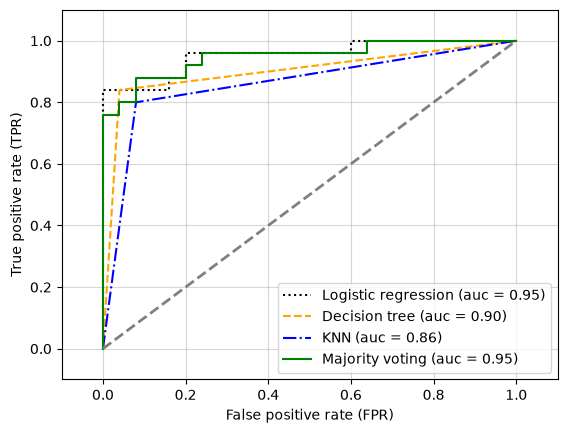

In [13]:
##### Evaluating and tuning the ensemble classifier

from sklearn.metrics import roc_curve
from sklearn.metrics import auc


colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls \
        in zip(all_clf,
               clf_labels, colors, linestyles):

    # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train,
                     y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test,
                                     y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label=f'{label} (auc = {roc_auc:.2f})')

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='gray',
         linewidth=2)

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')


#plt.savefig('figures/07_04', dpi=300)
plt.show()

In [14]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)

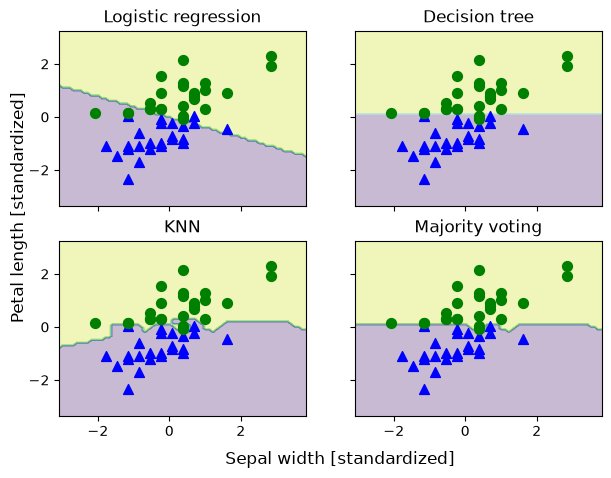

In [15]:
from itertools import product


all_clf = [pipe1, clf2, pipe3, mv_clf]

x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=2, ncols=2, 
                        sharex='col', 
                        sharey='row', 
                        figsize=(7, 5))

for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], 
                                  X_train_std[y_train==0, 1], 
                                  c='blue', 
                                  marker='^',
                                  s=50)
    
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], 
                                  X_train_std[y_train==1, 1], 
                                  c='green', 
                                  marker='o',
                                  s=50)
    
    axarr[idx[0], idx[1]].set_title(tt)

plt.text(-3.5, -5., 
         s='Sepal width [standardized]', 
         ha='center', va='center', fontsize=12)
plt.text(-12.5, 4.5, 
         s='Petal length [standardized]', 
         ha='center', va='center', 
         fontsize=12, rotation=90)

#plt.savefig('figures/07_05', dpi=300)
plt.show()

In [16]:
mv_clf.get_params()

{'pipeline-1': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf',
                  LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]]),
 'decisiontreeclassifier': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 'pipeline-2': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'pipeline-1__memory': None,
 'pipeline-1__steps': [('sc', StandardScaler()),
  ['clf', LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]],
 'pipeline-1__transform_input': None,
 'pipeline-1__verbose': False,
 'pipeline-1__sc': StandardScaler(),
 'pipeline-1__clf': LogisticRegression(C=0.001, l1_ratio=0, random_state=1),
 'pipeline-1__sc__copy': True,
 'pipeline-1__sc__with_mean': True,
 'pipeline-1__sc__with_std': True,
 'pipeline-1__clf__C': 0.001,
 'pipeline-1__clf__class_weight': None,
 'pipeline-1__clf__dual': False,
 'pipeline-1__clf__fit_intercept': True,
 'pipeline-1__clf__intercept_scaling': 1,

Based on the values returned by the get_params method, we now know how to access the individual
classifier’s attributes. Let’s now tune the inverse regularization parameter, C, of the logistic regression
classifier and the decision tree depth via a grid search for demonstration purposes:

In [17]:
from sklearn.model_selection import GridSearchCV


params = {'decisiontreeclassifier__max_depth': [1, 2],
          'pipeline-1__clf__C': [0.001, 0.1, 100.0]}

grid = GridSearchCV(estimator=mv_clf,
                    param_grid=params,
                    cv=10,
                    scoring='roc_auc')
grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MajorityVoteC...ghbors=1)]])])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__max_depth': [1, 2], 'pipeline-1__clf__C': [0.001, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Cont

After the grid search has completed, we can print the different hyperparameter value combinations
and the average ROC AUC scores computed via 10-fold cross-validation as follows:

In [18]:

for r, _ in enumerate(grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_dev = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f'{mean_score:.3f} +/- {std_dev:.2f} {params}')

0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 100.0}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}


In [19]:
print(f'Best parameters: {grid.best_params_}')
print(f'ROC AUC: {grid.best_score_:.2f}')

Best parameters: {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
ROC AUC: 0.98


**Note**  
By default, the default setting for `refit` in `GridSearchCV` is `True` (i.e., `GridSeachCV(..., refit=True)`), which means that we can use the fitted `GridSearchCV` estimator to make predictions via the `predict` method, for example:

    grid = GridSearchCV(estimator=mv_clf, 
                        param_grid=params, 
                        cv=10, 
                        scoring='roc_auc')
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

In addition, the "best" estimator can directly be accessed via the `best_estimator_` attribute.

In [20]:
grid.best_estimator_.classifiers

[Pipeline(steps=[('sc', StandardScaler()),
                 ['clf',
                  LogisticRegression(C=0.001, l1_ratio=0, random_state=1)]]),
 DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]])]

In [21]:
mv_clf = grid.best_estimator_

In [22]:
mv_clf.set_params(**grid.best_estimator_.get_params())

,pipeline-1,Pipeline(step...om_state=1))])
,decisiontreeclassifier,DecisionTreeC...andom_state=0)
,pipeline-2,Pipeline(step...eighbors=1))])
,pipeline-1__memory,None
,pipeline-1__steps,"[('sc', ...), ('clf', ...)]"
,pipeline-1__transform_input,None
,pipeline-1__verbose,False
,pipeline-1__sc,StandardScaler()
,pipeline-1__clf,LogisticRegre...andom_state=1)
,pipeline-1__sc__copy,True
,pipeline-1__sc__with_mean,True


In [23]:
mv_clf

,pipeline-1,Pipeline(step...om_state=1))])
,decisiontreeclassifier,DecisionTreeC...andom_state=0)
,pipeline-2,Pipeline(step...eighbors=1))])
,pipeline-1__memory,None
,pipeline-1__steps,"[('sc', ...), ('clf', ...)]"
,pipeline-1__transform_input,None
,pipeline-1__verbose,False
,pipeline-1__sc,StandardScaler()
,pipeline-1__clf,LogisticRegre...andom_state=1)
,pipeline-1__sc__copy,True
,pipeline-1__sc__with_mean,True


As you can see, we get the best cross-validation results when we choose a lower regularization strength
(C=0.001), whereas the tree depth does not seem to affect the performance at all, suggesting that a
decision stump is sufficient to separate the data. To remind ourselves that it is a bad practice to use
the test dataset more than once for model evaluation, we are not going to estimate the generalization
performance of the tuned hyperparameters in this section. We will move on swiftly to an alternative
approach for ensemble learning: bagging.

___

#### Building ensembles using stacking

The majority vote approach we implemented in this section is not to be confused with
stacking. The stacking algorithm can be understood as a two-level ensemble, where the
first level consists of individual classifiers that feed their predictions to the second lev-
el, where another classifier (typically logistic regression) is fit to the level-one classifier
predictions to make the final predictions. For more information on stacking, see the
following resources:

* The stacking algorithm has been described in more detail by David H. Wolp-
ert in Stacked generalization, Neural Networks, 5(2):241–259, 1992 (https://www.
sciencedirect.com/science/article/pii/S0893608005800231).
* Interested readers can find our video tutorial about stacking on YouTube at
https://www.youtube.com/watch?v=8T2emza6g80.
* A scikit-learn compatible version of a stacking classifier is available from
mlxtend: http://rasbt.github.io/mlxtend/user_guide/classifier/
StackingCVClassifier/.
* Also, a StackingClassifier has recently been added to scikit-learn (available in
version 0.22 and newer); for more information, please see the documentation at
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.
StackingClassifier.html.

___

#### 4.1.2 Bagging

Bagging stands for bootstrap aggregating, an ensemble learning method closely related to the majority vote method in previous section. Instead of using the same training dataset to fit the
individual classifiers in the ensemble, however, we draw bootstrap samples (random samples with replacement) from the initial training dataset. This concept is summarized in Figure 4.2 below

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_06.png" width=800 />

Figure 4.2 Bagging concept (from Figure 7.6 of [1])

let’s consider the example shown in Figure 4.3 Here, we have seven different training instances (denoted
as indices 1-7) that are sampled randomly with replacement in each round of bagging. Each
bootstrap sample is then used to fit a classifier, Cj, which is most typically an unpruned decision tree.

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_07.png" width=1000 />

Figure 4.3 An example of bagging (from Figure 7.7 of [1])

##### Applying bagging to classify examples in the Wine dataset

let’s create a more complex classification problem using the Wine dataset. Here, we will
only consider the Wine classes 2 and 3, and we will select two features – Alcohol and OD280/OD315
of diluted wines

In [24]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)

# drop 1 class
df_wine = df_wine[df_wine['Class label'] != 1]

y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

Encode the class labels into binary format and split the dataset into 80 percent training
and 20 percent test datasets.

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test =\
            train_test_split(X, y, 
                             test_size=0.2, 
                             random_state=1,
                             stratify=y)

In scikit-learn, import BaggingClassifier from ensemble submodule. We will use an unpruned decision tree as the base classifier and create an
ensemble of 500 decision trees fit on different bootstrap samples of the training dataset.

**Note :** From the code provided with [1], change *base_estimator* to *estimator*.  

In [26]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', 
                              max_depth=None,
                              random_state=1)

bag = BaggingClassifier(estimator=tree,
                        n_estimators=500, 
                        max_samples=1.0, 
                        max_features=1.0, 
                        bootstrap=True, 
                        bootstrap_features=False, 
                        n_jobs=1, 
                        random_state=1)

Calculate the accuracy score to compare the performance of bagging classifer with a unpruned decison tree.

In [27]:
from sklearn.metrics import accuracy_score


tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}')

bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)

bag_train = accuracy_score(y_train, y_train_pred) 
bag_test = accuracy_score(y_test, y_test_pred) 
print(f'Bagging train/test accuracies '
      f'{bag_train:.3f}/{bag_test:.3f}')

Decision tree train/test accuracies 1.000/0.833
Bagging train/test accuracies 1.000/0.917


Compare the decision regions.

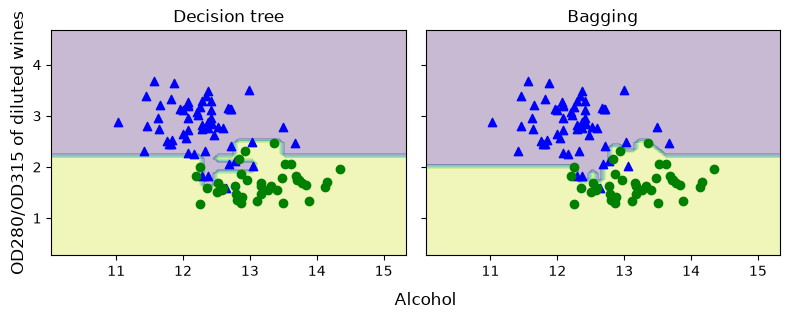

In [28]:
import numpy as np
import matplotlib.pyplot as plt


x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=1, ncols=2, 
                        sharex='col', 
                        sharey='row', 
                        figsize=(8, 3))


for idx, clf, tt in zip([0, 1],
                        [tree, bag],
                        ['Decision tree', 'Bagging']):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0],
                       X_train[y_train == 0, 1],
                       c='blue', marker='^')

    axarr[idx].scatter(X_train[y_train == 1, 0],
                       X_train[y_train == 1, 1],
                       c='green', marker='o')

    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)

plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)

plt.show()

The following materials are from [1].

We only looked at a very simple bagging example in this section. In practice, more complex classifi-
cation tasks and a dataset’s high dimensionality can easily lead to overfitting in single decision trees,
and this is where the bagging algorithm can really play to its strengths. Finally, we must note that
the bagging algorithm can be an effective approach to reducing the variance of a model. However,
bagging is ineffective in reducing model bias, that is, models that are too simple to capture the trends
in the data well. This is why we want to perform bagging on an ensemble of classifiers with low bias,
for example, unpruned decision trees.

### Leveraging weak learners via adaptive boosting

In this last section about ensemble methods, we will discuss boosting, with a special focus on its most
common implementation: **Adaptive Boosting (AdaBoost).**

___

**AdaBoost recognition**

The original idea behind AdaBoost was formulated by Robert E. Schapire in 1990 in The
Strength of Weak Learnability, Machine Learning, 5(2): 197-227, 1990, URL: http://rob.schapire.net/papers/strengthofweak.pdf. After Robert Schapire and Yoav Freund
presented the AdaBoost algorithm in the Proceedings of the Thirteenth International Confer-
ence (ICML 1996), AdaBoost became one of the most widely used ensemble methods in the
years that followed (Experiments with a New Boosting Algorithm by Y. Freund, R. E. Schapire,
and others, ICML, volume 96, 148-156, 1996). In 2003, Freund and Schapire received the
Gödel Prize for their groundbreaking work, which is a prestigious prize for the most out-
standing publications in the field of computer science.

___

In boosting, the ensemble consists of very simple base classifiers, also often referred to as weak
learners, which often only have a slight performance advantage over random guessing—a typical
example of a weak learner is a decision tree stump. The key concept behind boosting is to focus on
training examples that are hard to classify, that is, to let the weak learners subsequently learn from
misclassified training examples to improve the performance of the ensemble.

The following subsections will introduce the algorithmic procedure behind the general concept of
boosting and AdaBoost. Lastly, we will use scikit-learn for a practical classification example.

### How adaptive boosting works

In contrast to bagging, the initial formulation of the boosting algorithm uses random subsets of train-
ing examples drawn from the training dataset without replacement; the original boosting procedure
can be summarized in the following four key steps:

1. Draw a random subset (sample) of training examples, d1, without replacement from the training
dataset, D, to train a weak learner, C1.
2. Draw a second random training subset, d2, without replacement from the training dataset and
add 50 percent of the examples that were previously misclassified to train a weak learner, C2.
3. Find the training examples, d3, in the training dataset, D, which C1 and C2 disagree upon, to
train a third weak learner, C3.
4. Combine the weak learners C1, C2, and C3 via majority voting.

As discussed by Leo Breiman (Bias, variance, and arcing classifiers, 1996), boosting can lead to a decrease
in bias as well as variance compared to bagging models. In practice, however, boosting algorithms such
as AdaBoost are also known for their high variance, that is, the tendency to overfit the training data
(An improvement of AdaBoost to avoid overfitting by G. Raetsch, T. Onoda, and K. R. Mueller. Proceedings
of the International Conference on Neural Information Processing, CiteSeer, 1998).

In contrast to the original boosting procedure described here, AdaBoost uses the complete training
dataset to train the weak learners, where the training examples are reweighted in each iteration to
build a strong classifier that learns from the mistakes of the previous weak learners in the ensemble.
Before we dive deeper into the specific details of the AdaBoost algorithm, let’s take a look at Figure 7.9
to get a better grasp of the basic concept behind AdaBoost:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_09.png" width=1000 />

Figure 7.9: The concept of AdaBoost to improve weak learners

To walk through the AdaBoost illustration step by step, we will start with subfigure 1, which represents
a training dataset for binary classification where all training examples are assigned equal weights.
Based on this training dataset, we train a decision stump (shown as a dashed line) that tries to classify
the examples of the two classes (triangles and circles), as well as possibly minimizing the loss function
(or the impurity score in the special case of decision tree ensembles).

For the next round (subfigure 2), we assign a larger weight to the two previously misclassified examples
(circles). Furthermore, we lower the weight of the correctly classified examples. The next decision
stump will now be more focused on the training examples that have the largest weights—the training
examples that are supposedly hard to classify.

The weak learner shown in subfigure 2 misclassifies three different examples from the circle class,
which are then assigned a larger weight, as shown in subfigure 3.

Assuming that our AdaBoost ensemble only consists of three rounds of boosting, we then combine
the three weak learners trained on different reweighted training subsets by a weighted majority vote,
as shown in subfigure 4.

Now that we have a better understanding of the basic concept of AdaBoost, let’s take a more detailed
look at the algorithm using pseudo code. For clarity, we will denote element-wise multiplication by
the cross symbol (×) and the dot-product between two vectors by a dot symbol (⋅):
1.  Set the weight vector, $w$, to uniform weights, where $\sum_i w_i = 1$ .
2. For $j$ in $m$ boosting rounds, do the following:
<br>a. Train a weighted weak learner: $C_j = train(X,y,w)$.
<br>b. Predict class labels: $\hat{y} = predict(C_j, X)$.
<br>c. Compute the weighted error rate: $\epsilon = w \cdot (\hat{y} \ne y)$.
<br>d. Compute the coefficient: $\alpha_j = 0.5 \log \frac{1-\epsilon}{\epsilon}$.
<br>e. Update the weights: $w := w \times \exp(-\alpha_j \times \hat{y} \times y)$.
<br>f. Normalize the weights to sum to $1: w := w/\sum_i w_i$.
3. Compute the final prediction: $\hat{y} = \left(\sum_{j=1}^m(\alpha_j \times predict(C_j, X)) \gt 0 \right)$

Note that the expression $(\hat{y} \ne y)$ in step 2c refers to a binary vector consisting of 1s and 0s, where a 1
is assigned if the prediction is incorrect and 0 is assigned otherwise.

Although the AdaBoost algorithm seems to be pretty straightforward, let’s walk through a more con-
crete example using a training dataset consisting of 10 training examples, as illustrated in Figure 7.10:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_10.png" width=1000 />

Figure 7.10: Running 10 training examples through the AdaBoost algorithm

The first column of the table depicts the indices of training examples 1 to 10. In the second column,
you can see the feature values of the individual samples, assuming this is a one-dimensional dataset.
The third column shows the true class label, $y_i$, for each training sample, $x_i$, where $y_i \in \{1, −1\}$ . The
initial weights are shown in the fourth column; we initialize the weights uniformly (assigning the
same constant value) and normalize them to sum to 1. In the case of the 10-sample training dataset,
̂
we therefore assign 0.1 to each weight, $w_i$, in the weight vector, $w$. The predicted class labels, $\hat{y}$
, are
shown in the fifth column, assuming that our splitting criterion is $x \le 3.0$ . The last column of the
table then shows the updated weights based on the update rules that we defined in the pseudo code.

Since the computation of the weight updates may look a little bit complicated at first, we will now
follow the calculation step by step. We will start by computing the weighted error rate, $\epsilon$, as described in step 2c:


In [29]:
y = np.array([1, 1, 1, -1, -1, -1,  1,  1,  1, -1])
yhat = np.array([1, 1, 1, -1, -1, -1, -1, -1, -1, -1])
correct = (y == yhat)
weights = np.full(10, 0.1)
print(weights)

epsilon = np.mean(~correct)
print(epsilon)

[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
0.3


Note that correct is a Boolean array consisting of True and False values where True indicates that a
prediction is correct. Via ~correct, we invert the array such that np.mean(~correct) computes the
proportion of incorrect predictions (True counts as the value 1 and False as 0), that is, the classifica-
tion error.
Next, we will compute the coefficient, $\alpha_j$ —shown in step 2d—which will later be used in step 2e to update
the weights, as well as for the weights in the majority vote prediction (step 3):

In [30]:
alpha_j = 0.5 * np.log((1-epsilon) / epsilon)
print(alpha_j)

0.42364893019360184


After we have computed the coefficient, $\alpha_j$ (alpha_j), we can now update the weight vector using the
following equation:
$$
w := w \times \exp(-\alpha_j \times \hat{y} \times y)
$$

Here, $\hat{y} \times y_i$ an element-wise multiplication between the vectors of the predicted and true class labels,
respectively. Thus, if a prediction, $\hat{y}_i$, is correct, $\hat{y}_i \times y_i$ will have a positive sign so that we decreasethe ith weight, since $\alpha_j$ is a positive number as well:


In [31]:
update_if_correct = 0.1 * np.exp(-alpha_j * 1 * 1)
print(update_if_correct)

0.06546536707079771


Similarly, we will increase the ith weight if $\hat{y}_i$ predicted the label incorrectly, like this:

In [32]:
update_if_wrong_1 = 0.1 * np.exp(-alpha_j * 1 * -1)
print(update_if_wrong_1)

0.1527525231651947


Alternatively, it’s like this:

In [33]:
update_if_wrong_2 = 0.1 * np.exp(-alpha_j * -1 * 1)
print(update_if_wrong_2)

0.1527525231651947


We can use these values to update the weights as follows:

In [34]:
weights = np.where(correct == 1, update_if_correct, update_if_wrong_1)
print(weights)

[0.06546537 0.06546537 0.06546537 0.06546537 0.06546537 0.06546537
 0.15275252 0.15275252 0.15275252 0.06546537]


The code above assigned the update_if_correct value to all correct predictions and the update_if_
wrong_1 value to all wrong predictions. We omitted using update_if_wrong_2 for simplicity, since it
is similar to update_if_wrong_1 anyway.

After we have updated each weight in the weight vector, we normalize the weights so that they sum
up to 1 (step 2f):
$$
w := \frac{w}{\sum_i w_i}
$$
In code, we can accomplish that as follows:

In [35]:
normalized_weights = weights / np.sum(weights)
print(normalized_weights)

[0.07142857 0.07142857 0.07142857 0.07142857 0.07142857 0.07142857
 0.16666667 0.16666667 0.16666667 0.07142857]


Thus, each weight that corresponds to a correctly classified example will be reduced from the initial
value of 0.1 to 0.0714 for the next round of boosting. Similarly, the weights of the incorrectly classified
examples will increase from 0.1 to 0.1667.

### Applying AdaBoost using scikit-learn

The previous subsection introduced AdaBoost in a nutshell. Skipping to the more practical part, let’s
now train an AdaBoost ensemble classifier via scikit-learn. We will use the same Wine subset that we
used in the previous section to train the bagging meta-classifier.

Via the base_estimator attribute, we will train the AdaBoostClassifier on 500 decision tree stumps:

In [36]:
from sklearn.ensemble import AdaBoostClassifier


tree = DecisionTreeClassifier(criterion='entropy', 
                              max_depth=1,
                              random_state=1)

ada = AdaBoostClassifier(estimator=tree,
                         n_estimators=500, 
                         learning_rate=0.1,
                         random_state=1)

tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}')


Decision tree train/test accuracies 0.916/0.875


As you can see, the decision tree stump seems to underfit the training data in contrast to the unpruned
decision tree that we saw in the previous section:

In [37]:
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)

ada_train = accuracy_score(y_train, y_train_pred) 
ada_test = accuracy_score(y_test, y_test_pred) 
print(f'AdaBoost train/test accuracies '
      f'{ada_train:.3f}/{ada_test:.3f}')

AdaBoost train/test accuracies 0.968/0.917


Here, you can see that the AdaBoost model predicts all class labels of the training dataset correctly
and also shows a slightly improved test dataset performance compared to the decision tree stump.
However, you can also see that we introduced additional variance with our attempt to reduce the model
bias—a greater gap between training and test performance.

Although we used another simple example for demonstration purposes, we can see that the perfor-
mance of the AdaBoost classifier is slightly improved compared to the decision stump and achieved
very similar accuracy scores as the bagging classifier that we trained in the previous section. However,
we must note that it is considered bad practice to select a model based on the repeated usage of the test
dataset. The estimate of the generalization performance may be overoptimistic, which we discussed
in more detail in Chapter 6, Learning Best Practices for Model Evaluation and Hyperparameter Tuning.

Lastly, let’s check what the decision regions look like:

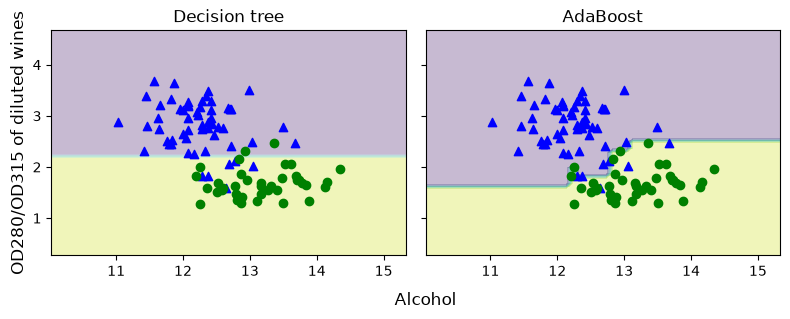

In [38]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(8, 3))


for idx, clf, tt in zip([0, 1],
                        [tree, ada],
                        ['Decision tree', 'AdaBoost']):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0],
                       X_train[y_train == 0, 1],
                       c='blue', marker='^')
    axarr[idx].scatter(X_train[y_train == 1, 0],
                       X_train[y_train == 1, 1],
                       c='green', marker='o')
    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)

plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)

plt.show()

Figure 7.11: The decision boundaries of the decision tree versus AdaBoost

By looking at the decision regions, you can see that the decision boundary of the AdaBoost model
is substantially more complex than the decision boundary of the decision stump. In addition, note
that the AdaBoost model separates the feature space very similarly to the bagging classifier that we
trained in the previous section:

As concluding remarks about ensemble techniques, it is worth noting that ensemble learning increases
the computational complexity compared to individual classifiers. In practice, we need to think care-
fully about whether we want to pay the price of increased computational costs for an often relatively
modest improvement in predictive performance.

An often-cited example of this tradeoff is the famous $1 million Netflix Prize, which was won using
ensemble techniques. The details about the algorithm were published in The BigChaos Solution to the
Netflix Grand Prize by A. Toescher, M. Jahrer, and R. M. Bell, Netflix Prize documentation, 2009, which
is available at http://www.stat.osu.edu/~dmsl/GrandPrize2009_BPC_BigChaos.pdf. The winning
team received the $1 million grand prize money; however, Netflix never implemented their model
due to its complexity, which made it infeasible for a real-world application:

___

“We evaluated some of the new methods offline but the additional accuracy gains that
we measured did not seem to justify the engineering effort needed to bring them into a
production environment.”
http://techblog.netflix.com/2012/04/netflix-recommendations-beyond-5-stars.html

___

## Gradient boosting – training an ensemble based on loss gradients

Gradient boosting is another variant of the boosting concept introduced in the previous section, that
is, successively training weak learners to create a strong ensemble. Gradient boosting is an extremely
important topic because it forms the basis of popular machine learning algorithms such as XGBoost,
which is well-known for winning Kaggle competitions.

The gradient boosting algorithm may appear a bit daunting at first. So, in the following subsections, we
will cover it step by step, starting with a general overview. Then, we will see how gradient boosting is
used for classification and walk through an example. Finally, after we’ve introduced the fundamental
concepts of gradient boosting, we will take a brief look at popular implementations, such as XGBoost,
and we will see how we can use gradient boosting in practice.

### Comparing AdaBoost with gradient boosting

Fundamentally, gradient boosting is very similar to AdaBoost, which we discussed previously in this
chapter. AdaBoost trains decision tree stumps based on errors of the previous decision tree stump. In
particular, the errors are used to compute sample weights in each round as well as for computing a clas-
sifier weight for each decision tree stump when combining the individual stumps into an ensemble. We
stop training once a maximum number of iterations (decision tree stumps) is reached. Like AdaBoost,
gradient boosting fits decision trees in an iterative fashion using prediction errors. However, gradient
boosting trees are usually deeper than decision tree stumps and have typically a maximum depth of
3 to 6 (or a maximum number of 8 to 64 leaf nodes). Also, in contrast to AdaBoost, gradient boosting
does not use the prediction errors for assigning sample weights; they are used directly to form the
target variable for fitting the next tree. Moreover, instead of having an individual weighting term for
each tree, like in AdaBoost, gradient boosting uses a global learning rate that is the same for each tree.

As you can see, AdaBoost and gradient boosting share several similarities but differ in certain key as-
pects. In the following subsection, we will sketch the general outline of the gradient boosting algorithm.

### Outlining the general gradient boosting algorithm

In this section, we will look at gradient boosting for classification. For simplicity, we will look at a
binary classification example. Interested readers can find the generalization to the multi-class setting
with logistic loss in Section 4.6. Multiclass logistic regression and classification of the original gradient
boosting paper written by Friedman in 2001, Greedy function approximation: A gradient boosting ma-
chine, https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-
function-approximation-A-gradient-boostingmachine/10.1214/aos/1013203451.full.

___

**Gradient boosting for regression** 

Note that the procedure behind gradient boosting is a bit more complicated than AdaBoost.
We omit a simpler regression example, which was given in Friedman’s paper, for brevity,
but interested readers are encouraged to also consider my complementary video tutorial
on gradient boosting for regression, which is available at: https://www.youtube.com/watch?v=zblsrxc7XpM.

___

In essence, gradient boosting builds a series of trees, where each tree is fit on the error—the difference
between the label and the predicted value—of the previous tree. In each round, the tree ensemble
improves as we are nudging each tree more in the right direction via small updates. These updates
are based on a loss gradient, which is how gradient boosting got its name.

The following steps will introduce the general algorithm behind gradient boosting. After illustrating
the main steps, we will dive into some of its parts in more detail and walk through a hands-on example
in the next subsections.

1. Initialize a model to return a constant prediction value. For this, we use a decision tree root
node; that is, a decision tree with a single leaf node. We denote the value returned by the tree as
$\hat{y}$ , and we find this value by minimizing a differentiable loss function L that we will define later:
$$
F_0(x) = \underset{\hat{y}}{arg\; min} \sum_{i=1}^{n}L(y_i, \hat{y})
$$
Here, $n$ refers to the $n$ training examples in our dataset.

2. For each tree $m = 1, \ldots, M$, where $M$ is a user-specified total number of trees, we carry out the
following computations outlined in steps 2a to 2d below:
<br>a. Compute the difference between a predicted value $F(x_i) = \hat{y}_i$ and the class label $y_i$. This
value is sometimes called the *pseudo-response* or *pseudo-residual*. More formally, we can
write this pseudo-residual as the negative gradient of the loss function with respect to
the predicted values:
$$
r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F(x)=F_{m-1}(x)} \text{for}\; i = 1, \ldots, n
$$
Note that in the notation above $F(x)$ is the prediction of the previous tree, $F_{m–1}(x)$. So, in
the first round, this refers to the constant value from the tree (single leaf node) from
step 1.
<br>b. Fit a tree to the pseudo-residuals $r_{im}$. We use the notation Rjm to denote the $j = 1, \ldots, J_m$
leaf nodes of the resulting tree in iteration $m$.
<br>c. For each leaf node $R_{jm}$, we compute the following output value:
$$
\gamma_{jm} = \underset{\gamma}{arg\; min} \sum_{x_i \in R_{jm}}L(y_i, F_{m-1}(x_i)+\gamma)
$$

In the next subsection, we will dive deeper into how this $\gamma_{jm}$ is computed by minimizing
the loss function. At this point, we can already note that leaf nodes $R_{jm}$ may contain
more than one training example, hence the summation.
<br>d. Update the model by adding the output values $\gamma_m$ to the previous tree:
$$
F_m(x) = F_{m-1}(x)+\eta \gamma_m
$$
However, instead of adding the full predicted values of the current tree $\gamma_m$ to the previ-
ous tree $F_{m-1}$ , we scale $\gamma_m$ by a learning rate $\eta$ , which is typically a small value between
0.01 and 1. In other words, we update the model incrementally by taking small steps,
which helps avoid overfitting.

Now, after looking at the general structure of gradient boosting, we will adopt these mechanics to look
at gradient boosting for classification.

### Explaining the gradient boosting algorithm for classification

In this subsection, we will go over the details for implementing the gradient boosting algorithm for
binary classification. In this context, we will be using the logistic loss function that we introduced for
logistic regression in Chapter 3, A Tour of Machine Learning Classifiers Using Scikit-Learn. For a single
training example, we can specify the logistic loss as follows:
$$
L_i = -y_i \log p_i + (1 - y_i) \log (1-p_i)
$$
In Chapter 3, we also introduced the log(odds):
$$
\hat{y} = \log(odds) = \log \left(\frac{p}{1-p}\right)
$$
For reasons that will make sense later, we will use these log(odds) to rewrite the logistic function as
follows (omitting intermediate steps here):
$$
L_i = \log(1 + e^{\hat{y}_i}) - y_i \hat{y}_i
$$

Now, we can define the partial derivative of the loss function with respect to these log(odds), 𝑦𝑦𝑦 . The
derivative of this loss function with respect to the log(odds) is:
$$
\frac{\partial L_i}{\partial \hat{y}_i} = \frac{e^{\hat{y}_i}}{1 +e^{\hat{y}_i}} l- y_i = p_i - y_i
$$
After specifying these mathematical definitions, let us now revisit the general gradient boosting steps
1 to 2d from the previous section and reformulate them for this binary classification scenario.

1. Create a root node that minimizes the logistic loss. It turns out that the loss is minimized if
the root node returns the log(odds), $\hat{y}$ .
2. For each tree $M = 1, \ldots, M$, where $M$ is a user-specified number of total trees, we carry out the
following computations outlined in steps 2a to 2d:
<br>a. We convert the log(odds) into a probability using the familiar logistic function that we
used in logistic regression (in Chapter 3):
$$
p = \frac{1}{1+e^{-\hat{y}}}
$$
Then, we compute the pseudo-residual, which is the negative partial derivative of the
loss with respect to the log(odds), which turns out to be the difference between the
class label and the predicted probability:
$$
-\frac{\partial L_i}{\partial \hat{y}_i} = y_i - p_i
$$
<br>b. Fit a new tree to the pseudo-residuals.
<br>c. For each leaf node $R_{jm}$, compute a value $\gamma_{jm}$ that minimizes the logistic loss function.
This includes a summarization step for dealing with leaf nodes that contain multiple
training examples:
$$
\begin{align*}
\gamma_{jm} &= \underset{\gamma}{arg \;min} \sum_{x_i \in R_{jm}}L(y_i, F_{m-1}(x_i)+ \gamma) \\
&= \log(1 + e^{\hat{y}_i + y}) - y_i(\hat{y}_i + \gamma)
\end{align*}
$$
Skipping over intermediate mathematical details, this results in the following:
$$
\gamma_{jm} = \frac{\sum_i y_i - p_i}{\sum_i p_i(i - p_i)}
$$
Note that the summation here is only over the examples at the node corresponding to
the leaf node $R_{jm}$ and not the complete training set.
<br>d. Update the model by adding the gamma value from step 2c with learning rate $\eta$ :
$$
F_m(x) = F_{m-1}(x)+ \eta \gamma_m
$$


___
**Outputting log(odds) vs probabilities**

Why do the trees return log(odds) values and not probabilities? This is because we cannot
just add up probability values and arrive at a meaningful result. (So, technically speaking,
gradient boosting for classification uses regression trees.)
___

In this section, we adopted the general gradient boosting algorithm and specified it for binary classi-
fication, for instance, by replacing the generic loss function with the logistic loss and the predicted
values with the log(odds). However, many of the individual steps may still seem very abstract, and in
the next section, we will apply these steps to a concrete example.

### Illustrating gradient boosting for classification

The previous two subsections went over the condensed mathematical details of the gradient boosting
algorithm for binary classification. To make these concepts clearer, let’s apply it to a small toy example,
that is, a training dataset of the following three examples shown in Figure 7.12:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_12.png" width=600 />

Figure 7.12: Toy dataset for explaining gradient boosting

Let’s start with step 1, constructing the root node and computing the log(odds), and step 2a, converting
the log(odds) into class-membership probabilities and computing the pseudo-residuals. Note that based
on what we have learned in Chapter 3, the odds can be computed as the number of successes divided
by the number of failures. Here, we regard label 1 as success and label 0 as failure, so the odds are
computed as: odds = 2/1. Carrying out steps 1 and 2a, we get the following results shown in Figure 7.13:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_13.png" width=1200 />

Figure 7.13: Results from the first round of applying step 1 and step 2a

Next, in step 2b, we fit a new tree on the pseudo-residuals $r$. Then, in step 2c, we compute the output
values, $\gamma$ , for this tree as shown in Figure 7.14:

 <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_14.png" width=1000 />

Figure 7.14: An illustration of steps 2b and 2c, which fits a tree to the residuals and computes the
output values for each leaf node

(Note that we artificially limit the tree to have only two leaf nodes, which helps illustrate what happens
if a leaf node contains more than one example.)

Then, in the final step 2d, we update the previous model and the current model. Assuming a learning
rate of $\eta = 0.1$ , the resulting prediction for the first training example is shown in Figure 7.15:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_15.png" width=1000 />

Figure 7.15: The update of the previous model shown in the context of the first training example

Now that we have completed steps 2a to 2d of the first round, $m = 1$ we can proceed to execute steps 2a
to 2d for the second round, $m = 2$ In the second round, we use the log(odds) returned by the updated
model, for example, $F_1(x_1) = 0.839$ , as input to step 2A. The new values we obtain in the second round
are shown in Figure 7.16:

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_16.png" width=1000 />

Figure 7.16: Values from the second round next to the values from the first round

We can already see that the predicted probabilities are higher for the positive class and lower for the
negative class. Consequently, the residuals are getting smaller, too. Note that the process of steps 2a
to 2d is repeated until we have fit $M$ trees or the residuals are smaller than a user-specified threshold
value. Then, once the gradient boosting algorithm has completed, we can use it to predict the class
labels by thresholding the probability values of the final model, $F_M(x)$ at 0.5, like logistic regression in
Chapter 3. However, in contrast to logistic regression, gradient boosting consists of multiple trees and
produces nonlinear decision boundaries. In the next section, we will look at how gradient boosting
looks in action.

### Using XGBoost

After covering the nitty-gritty details behind gradient boosting, let’s finally look at how we can use
gradient boosting code implementations.

In scikit-learn, gradient boosting is implemented as sklearn.ensemble.GradientBoostingClassifier
(see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.
GradientBoostingClassifier.html for more details). It is important to note that gradient boosting
is a sequential process that can be slow to train. However, in recent years a more popular implemen-
tation of gradient boosting has emerged, namely, XGBoost.

XGBoost proposed several tricks and approximations that speed up the training process substantially.
Hence, the name XGBoost, which stands for extreme gradient boosting. Moreover, these approxima-
tions and tricks result in very good predictive performances. In fact, XGBoost gained popularity as it
has been the winning solution for many Kaggle competitions.

Next to XGBoost, there are also other popular implementations of gradient boosting, for ex-
ample, LightGBM and CatBoost. Inspired by LightGBM, scikit-learn now also implements a
HistGradientBoostingClassifier, which is more performant than the original gradient boosting
classifier (GradientBoostingClassifier).

You can find more details about these methods via the resources below:

* XGBoost: https://xgboost.readthedocs.io/en/stable/
* LightGBM: https://lightgbm.readthedocs.io/en/latest/
* CatBoost: https://catboost.ai
* HistGradientBoostingClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html

However, since XGBoost is still among the most popular gradient boosting implementations, we will
see how we can use it in practice. First, we need to install it, for example via pip:
```python
pip install xgboost
```
___
(This is installation note from book. It could be obsolete.)
**Installing XGBoost**

For this chapter, we used XGBoost version 1.5.0, which can be installed via:
```python
pip install XGBoost==1.5.0
```
You can find more information about the installation details at https://xgboost.readthedocs.io/en/stable/install.html

___

Fortunately, XGBoost’s XGBClassifier follows the scikit-learn API. So, using it is relatively straight-
forward:

In [39]:
import xgboost as xgb

In [40]:
model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=4, random_state=1, use_label_encoder=False)


gbm = model.fit(X_train, y_train)

y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

gbm_train = accuracy_score(y_train, y_train_pred) 
gbm_test = accuracy_score(y_test, y_test_pred) 
print(f'XGboost train/test accuracies '
      f'{gbm_train:.3f}/{gbm_test:.3f}')

/Users/dewdotninja/Desktop/courses/y2026/s1/mlpi/labs/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:12:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGboost train/test accuracies 0.968/0.917


Here, we fit the gradient boosting classifier with 1,000 trees (rounds) and a learning rate of 0.01. Typi-
cally, a learning rate between 0.01 and 0.1 is recommended. However, remember that the learning rate
is used for scaling the predictions from the individual rounds. So, intuitively, the lower the learning
rate, the more estimators are required to achieve accurate predictions.

Next, we have the max_depth for the individual decision trees, which we set to 4. Since we are still
boosting weak learners, a value between 2 and 6 is reasonable, but larger values may also work well
depending on the dataset.

Finally, use_label_encoder=False disables a warning message which informs users that XGBoost is
not converting labels by default anymore, and it expects users to provide labels in an integer format
starting with label 0. (There is nothing to worry about here, since we have been following this format
throughout this book.)

There are many more settings available, and a detailed discussion is out of the scope of this book.
However, interested readers can find more details in the original documentation at https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBClassifier.

### Summary

In this chapter, we looked at some of the most popular and widely used techniques for ensemble
learning. Ensemble methods combine different classification models to cancel out their individual
weaknesses, which often results in stable and well-performing models that are very attractive for
industrial applications as well as machine learning competitions.

At the beginning of this chapter, we implemented MajorityVoteClassifier in Python, which allows
us to combine different algorithms for classification. We then looked at bagging, a useful technique
for reducing the variance of a model by drawing random bootstrap samples from the training dataset
and combining the individually trained classifiers via majority vote. Lastly, we learned about boosting
in the form of AdaBoost and gradient boosting, which are algorithms based on training weak learners
that subsequently learn from mistakes.

Throughout the previous chapters, we learned a lot about different learning algorithms, tuning, and
evaluation techniques. In the next chapter, we will look at a particular application of machine learn-
ing, sentiment analysis, which has become an interesting topic in the internet and social media era.



___

### Random forest materials from lecture 2 notebook, for easy reference

## 5.3 Random forests

A random forest can be considered as an ensemble of decision trees. The idea behind a random forest is to average multiple (deep) decisiontrees that individually suffer from high variance to build a more robust model that has a better generalization performance and is less susceptible to overfitting. The random forest algorithm can be summarized in four simple steps:

1. Draw a random bootstrap sample of size $n$ (randomly choose $n$ examples from the training
dataset with replacement).
2. Grow a decision tree from the bootstrap sample. At each node:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; a. Randomly select $d$ features without replacement.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; b. Split the node using the feature that provides the best split according to the objective
function, for instance, maximizing the information gain.

3. Repeat steps 1-2 $k$ times.
4. Aggregate the prediction by each tree to assign the class label by majority vote. 

Use scikit-learn to grow a random forest for iris classification. 


In [1]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

Class labels: [0 1 2]
Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


In [2]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# To check recent matplotlib compatibility
import matplotlib
from distutils.version import LooseVersion


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')        

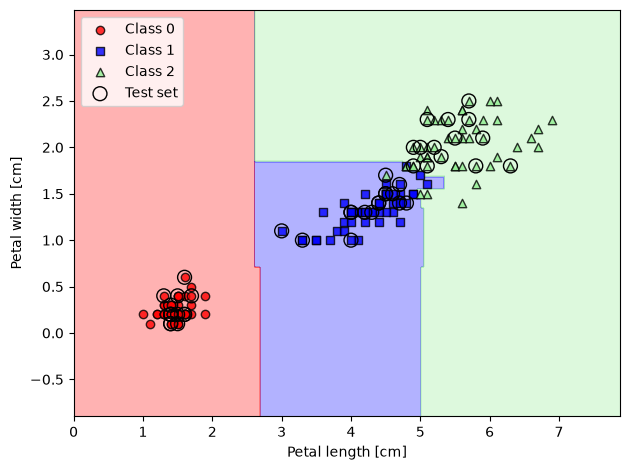

In [3]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=25, 
                                random_state=1,
                                n_jobs=2)
forest.fit(X_train, y_train)

plot_decision_regions(X_combined, y_combined, 
                      classifier=forest, test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

___

## From chapter 4 (p 134) of [1]

### Assessing feature importance with random forests

In previous sections, you learned how to use L1 regularization to zero out irrelevant features via logistic
regression and how to use the SBS algorithm for feature selection and apply it to a KNN algorithm.
Another useful approach for selecting relevant features from a dataset is using a random forest, an en-
semble technique that was introduced in Chapter 3. Using a random forest, we can measure the feature
importance as the averaged impurity decrease computed from all decision trees in the forest, without
making any assumptions about whether our data is linearly separable or not. Conveniently, the random
forest implementation in scikit-learn already collects the feature importance values for us so that we
can access them via the feature_importances_ attribute after fitting a RandomForestClassifier. By
executing the following code, we will now train a forest of 500 trees on the Wine dataset and rank the
13 features by their respective importance measures—remember from our discussion in Chapter 3 that
we don’t need to use standardized or normalized features in tree-based models:


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
# Code to prepare wine dataset from chapter 4 of [1]
df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                      'ml/machine-learning-databases/wine/wine.data',
                      header=None)

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)


df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

print('Class labels', np.unique(df_wine['Class label']))
df_wine.head()


Class labels [1 2 3]


,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test =\
    train_test_split(X, y, 
                     test_size=0.3, 
                     random_state=0, 
                     stratify=y)

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


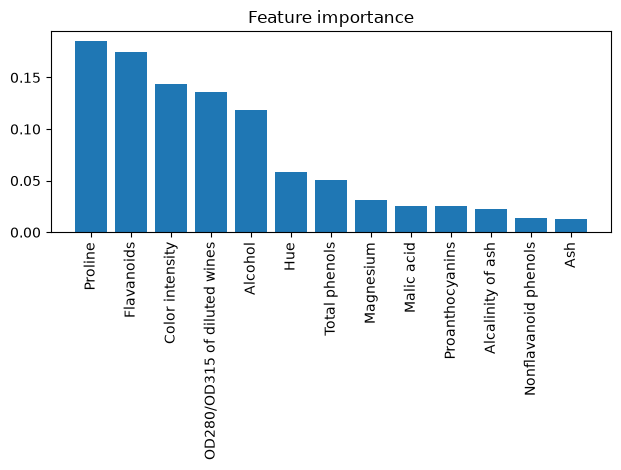

In [10]:
from sklearn.ensemble import RandomForestClassifier

feat_labels = df_wine.columns[1:]

forest = RandomForestClassifier(n_estimators=500,
                                random_state=1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))

plt.title('Feature importance')
plt.bar(range(X_train.shape[1]), 
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]), 
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
# plt.savefig('figures/04_10.png', dpi=300)
plt.show()

Figure 4.10: Random forest-based feature importance of the Wine dataset

After executing the code, we created a plot that ranks the different features in the Wine dataset by their
relative importance; note that the feature importance values are normalized so that they sum up to 1.0:

We can conclude that the proline and flavonoid levels, the color intensity, the OD280/OD315 diffraction,
and the alcohol concentration of wine are the most discriminative features in the dataset based on
the average impurity decrease in the 500 decision trees. Interestingly, two of the top-ranked features
in the plot are also in the three-feature subset selection from the SBS algorithm that we implemented
in the previous section (alcohol concentration and OD280/OD315 of diluted wines).

However, as far as interpretability is concerned, the random forest technique comes with an import-
ant gotcha that is worth mentioning. If two or more features are highly correlated, one feature may
be ranked very highly while the information on the other feature(s) may not be fully captured. On
the other hand, we don’t need to be concerned about this problem if we are merely interested in the
predictive performance of a model rather than the interpretation of feature importance values.

To conclude this section about feature importance values and random forests, it is worth mentioning
that scikit-learn also implements a SelectFromModel object that selects features based on a user-spec-
ified threshold after model fitting, which is useful if we want to use the RandomForestClassifier as
a feature selector and intermediate step in a scikit-learn Pipeline object, which allows us to connect
different preprocessing steps with an estimator, as you will see in Chapter 6, Learning Best Practices
for Model Evaluation and Hyperparameter Tuning. For example, we could set the threshold to 0.1 to
reduce the dataset to the five most important features using the following code:

In [11]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(forest, threshold=0.1, prefit=True)
X_selected = sfm.transform(X_train)
print('Number of features that meet this threshold criterion:', 
      X_selected.shape[1])

Number of features that meet this threshold criterion: 5


In [12]:
for f in range(X_selected.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, 
                            feat_labels[indices[f]], 
                            importances[indices[f]]))

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529


### Related Videos
<ul>
<li />Intro to ML and statistical by Sebastian Raschka, <a href=https://youtube.com/playlist?list=PLTKMiZHVd_2KyGirGEvKlniaWeLOHhUF3&si=kV3ueM1RM3cIGQfb>Playlist</a>
<ul>
<li /><a href="https://sebastianraschka.com/blog/2021/ml-course.html#l07---ensemble-methods">Ensemble methods (7.1 - 7.7)</a>
</ul>
</ul>



### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  


2. S. Raschka. [Introduction to Machine Learning course](https://sebastianraschka.com/blog/2021/ml-course.html). L07 :[Slides](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/07-ensembles__slides.pdf) [Notes](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/07-ensembles__notes.pdf) [Code](https://github.com/rasbt/stat451-machine-learning-fs20/blob/master/L07/code/07_code-from-slides.ipynb). University of Wisconsin, Madison. 2021



<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>